In [1]:
!pip install langchain langgraph langchain-community chromadb sqlite-utils


In [9]:
!pip install grandalf

  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 2/2 [grandalf]



In [12]:
# ==================================================
# 1. 기본 설정
# ==================================================
from typing import TypedDict
from langchain.prompts import PromptTemplate
from langgraph.graph import StateGraph, END

# AgentState 정의
class AgentState(TypedDict):
    query: str
    symptoms: str
    exercise_candidates: str
    result: str


# ==================================================
# 2. 에이전트 정의
# ==================================================

# 사용자 질문에서 증상 추출
extractor_prompt = PromptTemplate.from_template("""
사용자의 질문에서 증상에 해당하는 단어 또는 구를 추출하세요.
결과는 쉼표로 구분된 문자열로 출력하세요.

질문: {query}
""")

def extractor_agent(state: AgentState):
    chain = extractor_prompt | llm
    symptoms = chain.invoke({"query": state["query"]})

    return {**state, "symptoms": symptoms.strip()}


# 증상을 해결할 수 있는 운동 리스트 추출
candidate_prompt = PromptTemplate.from_template("""
다음 증상 목록을 바탕으로 도움이 될 수 있는 운동 리스트를 추천하세요.

증상: {symptoms}

조건:
- 현실적으로 할 수 있는 운동만 추천하세요.
- 운동 이름만 쉼표로 구분해서 출력하세요.
- 무리한 고강도 운동은 제외하세요.
- 한국어로 작성하세요.
""")

def candidate_agent(state: AgentState):
    chain = candidate_prompt | llm
    exercise_candidates = chain.invoke({
        "symptoms": state["symptoms"]
    })

    return {**state, "exercise_candidates": exercise_candidates.strip()}


# 증상과 운동 리스트를 개조식으로 최종 출력
answer_prompt = PromptTemplate.from_template("""
사용자의 증상은 다음과 같습니다.

증상:
{symptoms}

추천 운동 리스트:
{exercise_candidates}

위 내용을 바탕으로 사용자에게 알기 쉽게 개조식으로 답변하세요.

출력 형식:

### 추출된 증상
- 증상 1
- 증상 2

### 추천 운동
- 운동명: 추천 이유
- 운동명: 추천 이유

### 운동 시 주의사항
- 주의사항 1
- 주의사항 2

반드시 한국어로 작성하세요.
""")

def answer_agent(state: AgentState):
    chain = answer_prompt | llm
    answer = chain.invoke({
        "symptoms": state["symptoms"],
        "exercise_candidates": state["exercise_candidates"]
    })

    return {**state, "result": answer.strip()}


# ==================================================
# 3. LangGraph 정의
# ==================================================
graph = StateGraph(AgentState)

graph.add_node("extractor", extractor_agent)
graph.add_node("candidate", candidate_agent)
graph.add_node("answer", answer_agent)

graph.set_entry_point("extractor")

graph.add_edge("extractor", "candidate")
graph.add_edge("candidate", "answer")
graph.add_edge("answer", END)

app = graph.compile()


# ==================================================
# 4. 그래프 구조 출력
# ==================================================
print("============================== LangGraph 구조:")
app.get_graph().print_ascii()


# ==================================================
# 5. 실행 예시
# ==================================================
query = "체력이 안좋고, 살이 계속 찌는데 어떤 운동을 할까?"

result = app.invoke({
    "query": query
})

print("============================== 최종 응답:")
print(result["result"])

============================== LangGraph 구조:
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| extractor |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| candidate |  
+-----------+  
      *        
      *        
      *        
  +--------+   
  | answer |   
  +--------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   
============================== 최종 응답:
### 추출된 증상
- 체력 저하 및 지속적인 체중 증가

### 추천 운동
- **산책**: 낮은 부담으로 유산소 운동 효과가 있어 체력 증진과 체중 관리에 도움이 됩니다.
- **천천히 걷기**: 운동 강도가 낮아 쉽게 시작할 수 있으며, 꾸준히 실천하면 건강한 체중 유지에 효과적입니다.
- **수영**: 전신 운동으로 심폐 기능 향상과 함께 근력 강화 및 칼로리 소모가 빠르게 이루어져 체중 조절에 유리합니다.
- **요가**: 유연성 향상과 스트레스 해소에 효과적이며, 가벼운 근력 강화 운동을 포함할 수 있어 균형 잡힌 체력 관리에 적합합니다.
- **실내 자전거 타기**: 빠른 칼로리 소모와 심폐 기능 강화에 좋으며, 다양한 속도 조절로 체력 증가에 효과적입니다.
- **가벼운 근력 운동 (덤벨이나 가벼운 무게 사용)**: 근육 강화를 통해 기초 대사량 증가와 함께 체중 감량 및 체력 증진에 도움이 됩니다.

### 운동 시 주의사항
- **주의사항

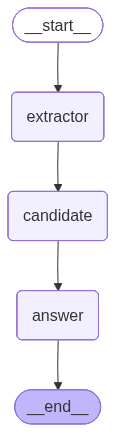

In [13]:
app